<a href="https://colab.research.google.com/github/AKookani/BrickwallCliffordCircuit/blob/main/Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dependencies

In [1]:
!pip install qiskit ipywidgets
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=b88033ed139be3a5f3545bb9b7ab87df4759e91fc3e64a6cdc6ebc3716ad0449
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
import numpy as np
import qiskit
import qiskit.quantum_info as qi
import matplotlib.pyplot as plt

In [3]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 47.7 MB/s eta 0:00:00


In [4]:
rng = np.random.default_rng() # Random Number Generator

# Stabilizer Entropy

## Explanation

**Gottesman entropy calculation**
* **Restricting the stabilizer generators to a subsystem $A$** yealds $A$'s entropy.
* Some stabilizers remain entirely inside ($A$), while others are "cut" by the partition and connect ($A$) to the rest of the system.
* The **number of independent stabilizers lost across the cut** tells you how much information ($A$) shares with its complement.
* Specifically,

  $
  S(A) = |A| - \operatorname{rank}(G_A),
  $

  where:

  * ($|A|$) is the number of qubits in subsystem ($A$),
  * ($G_A$) is the matrix of stabilizers supported entirely on ($A$).

## GF(2) Rank

**Rank of a binary matrix over GF(2) via Gaussian elimination**

In [5]:
def gf2_rank(matrix):
    m = (matrix.copy() % 2).astype(np.uint8)
    rows, cols = m.shape
    rank = 0
    for col in range(cols):
        pivot = None
        for r in range(rank, rows):
            if m[r, col]:
                pivot = r
                break
        if pivot is None:
            continue
        m[[rank, pivot]] = m[[pivot, rank]]
        for r in range(rows):
            if r != rank and m[r, col]:
                m[r] = (m[r] + m[rank]) % 2
        rank += 1
    return rank

## Explanations of the code above

For a binary matrix $(A)$ over $(GF(2))$, the rank is:

$$
\boxed{\operatorname{rank}_{GF(2)}(A)=\text{number of pivot columns after Gaussian elimination over }GF(2)}
$$

$$
\boxed{{GF(2)=\{0,1}\}}
$$

$GF(2)$ is the finite field with two elements, where arithmetic is done modulo (2)



After reducing $(A)$ to **row-echelon form** to eliminate entries below each pivot:

$$
A \xrightarrow{\text{Gaussian elimination over }GF(2)}
\begin{bmatrix}
1&*&*&\\
0&1&*&\\
0&0&1\\
0&0&0
\end{bmatrix}
$$

the rank is the number of nonzero rows (equivalently, the number of pivots).


## Entropy of an Ancilla

In [6]:
def ancilla_entropy(state, ancilla_col=0):
    """S_A = rank_GF2(stabilizer restricted to A) - |A|, for a 1-qubit ancilla."""
    cliff = state.clifford #Get the Clifford representation
    x_col = cliff.stab_x[:, ancilla_col:ancilla_col+1].astype(np.uint8) #Extract the X stabilizers of ancilla
    z_col = cliff.stab_z[:, ancilla_col:ancilla_col+1].astype(np.uint8) #Extract the Z stabilizers of ancilla
    M_A = np.concatenate([x_col, z_col], axis=1) #Build the restricted stabilizer matrix
    return gf2_rank(M_A) - 1 #Yeald the entropy

This function computes the **entropy of a single ancilla qubit** in a stabilizer state using the stabilizer formalism, which for following formula:

$$
S_A = \operatorname{rank}_{GF(2)}(M_A) - |A|,
$$


* ($M_A$) is the stabilizer generator matrix restricted to subsystem ($A$),
* ($|A|=1$) because the subsystem is a single qubit.



#Random brickwork Clifford

In [7]:
def brickwork_layer(state, system_qubits, t, periodic=True):
    """One staggered even/odd brickwork layer of random 2-qubit Cliffords."""
    L = len(system_qubits) #Get system size
    offset = t % 2 #Determine whether this is an even or odd layer
    j = offset #Start brickwork at the correct qubit
    while j + 1 < L:
        u2 = qi.random_clifford(2) #Create a random two-qubit Clifford gates
        state = state.evolve( #Applies generated u2 to the selected neighboring qubits
            qi.Clifford(u2), qargs=[system_qubits[j], system_qubits[j+1]]
            )
        j += 2
    if periodic and offset == 1 and L % 2 == 0: #Periodic boundary condition
        u2 = qi.random_clifford(2) #Create a random two-qubit Clifford gates
        state = state.evolve( #Applies generated u2 to the selected neighboring qubits
            qi.Clifford(u2), qargs=[system_qubits[L-1], system_qubits[0]]
            )
    return state #Return updated state

This function implements **one layer of a 1D brickwork quantum circuit** made of **random two-qubit Clifford gates**. It applies gates in an alternating even/odd pattern, which is common in quantum information simulations of random circuits, scrambling, and entanglement dynamics.

# Measurement

In [8]:
def measure_layer(state, system_qubits, p_measure):
    """Independently measure EACH system qubit with probability p_measure."""
    for q in system_qubits: #Loop over each qubit of the system
        if rng.random() < p_measure: #Random decision
            outcome, state = state.measure([q])
    return state

This function **randomly performs measurements on individual qubits in a quantum state** with a given probability.

#Trajectory

In [24]:
def run_trajectory(size, T, p_measure, t_scramble=0, periodic=True):
  #Create registers
    Ancilla = qiskit.QuantumRegister(1, 'ancilla')
    System = qiskit.QuantumRegister(size, 'system')
    qc = qiskit.QuantumCircuit(Ancilla, System)
    system_qubits = list(range(1, size + 1))  # Define system qubit indices; ancilla = 0

    if t_scramble > 0: # Optional Scrambling
        # Phase 1: scramble the system ALONE, no ancilla coupling yet
        qc_sys = qiskit.QuantumCircuit(size)
        state = qi.StabilizerState(qc_sys)
        for t in range(t_scramble):
            state = brickwork_layer(state, list(range(size)), t, periodic=periodic)
        # rebuild as (ancilla + system), then couple
        full_qc = qiskit.QuantumCircuit(Ancilla, System)
        state = qi.StabilizerState(full_qc).evolve(qi.Clifford(state.clifford.to_circuit()),
                                                  qargs=list(range(1, size + 1)))
        state = state.evolve(qi.Clifford(qiskit.QuantumCircuit(1).compose(qiskit.QuantumCircuit(1))), qargs=[0])  # no-op, ancilla stays |0>
        qc2 = qiskit.QuantumCircuit(1)
        qc2.h(0)
        state = state.evolve(qi.Clifford(qc2), qargs=[0])
        cx = qiskit.QuantumCircuit(2); cx.cx(0, 1)
        state = state.evolve(qi.Clifford(cx), qargs=[0, size // 2 + 1])
    else:
        qc.h(Ancilla)
        qc.cx(Ancilla, System[size // 2])
        state = qi.StabilizerState(qc)

    entropy_history = np.zeros(T)
    for t in range(T):
      if t == 0:
        entropy_history[t] = ancilla_entropy(state, ancilla_col=0)
      else:
        state = brickwork_layer(state, system_qubits, t, periodic=periodic)
        state = measure_layer(state, system_qubits, p_measure)
        entropy_history[t] = ancilla_entropy(state, ancilla_col=0)
    return entropy_history

#Plot

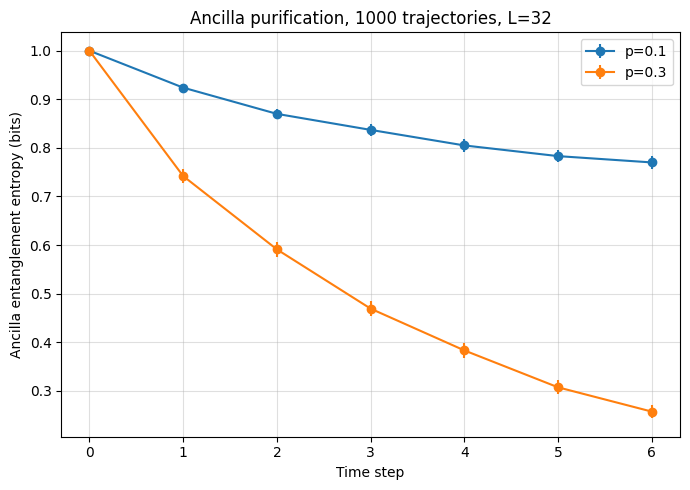

CPU times: user 12min 34s, sys: 1.7 s, total: 12min 35s
Wall time: 12min 50s


In [25]:
%%time
def run_averaged(size, T, p_measure, n_trials=200, t_scramble=0, periodic=True):
    all_S = np.zeros((n_trials, T))
    for k in range(n_trials):
        all_S[k] = run_trajectory(size, T, p_measure, t_scramble=t_scramble, periodic=periodic)
    return all_S.mean(axis=0), all_S.std(axis=0) / np.sqrt(n_trials)

# --- Run and plot ---
size = 512          # even size -> clean periodic brickwork, matches the paper's 2L convention
T = 15
n_trials = 1000

plt.figure(figsize=(7, 5))
for p in [0.1, 0.3]:
    mean_S, sem_S = run_averaged(size, T, p, n_trials=n_trials)
    plt.errorbar(range(0, T), mean_S, yerr=sem_S, marker='o', label=f"p={p}")

plt.xlabel("Time step")
plt.ylabel("Ancilla entanglement entropy (bits)")
plt.title(f"Ancilla purification, {n_trials} trajectories, L={size}")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

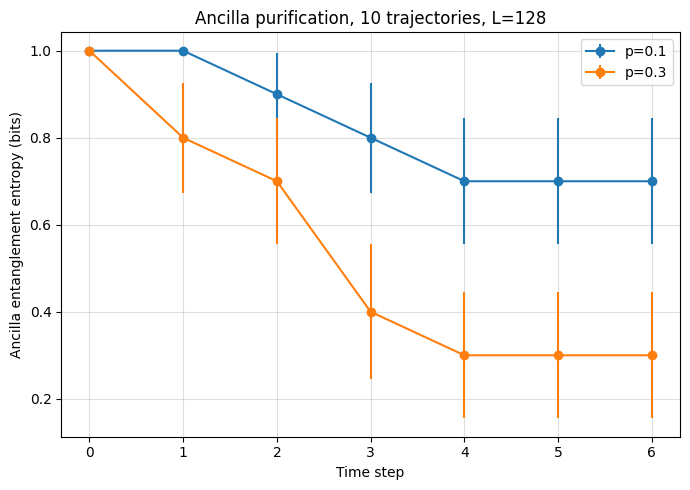

CPU times: user 4min 50s, sys: 305 ms, total: 4min 51s
Wall time: 4min 58s


In [28]:
%%time
def run_averaged(size, T, p_measure, n_trials=200, t_scramble=0, periodic=True):
    all_S = np.zeros((n_trials, T))
    for k in range(n_trials):
        all_S[k] = run_trajectory(size, T, p_measure, t_scramble=t_scramble, periodic=periodic)
    return all_S.mean(axis=0), all_S.std(axis=0) / np.sqrt(n_trials)

# --- Run and plot ---
size = 128          # even size -> clean periodic brickwork, matches the paper's 2L convention
T = 7
n_trials = 10

plt.figure(figsize=(7, 5))
for p in [0.1, 0.3]:
    mean_S, sem_S = run_averaged(size, T, p, n_trials=n_trials)
    plt.errorbar(range(0, T), mean_S, yerr=sem_S, marker='o', label=f"p={p}")

plt.xlabel("Time step")
plt.ylabel("Ancilla entanglement entropy (bits)")
plt.title(f"Ancilla purification, {n_trials} trajectories, L={size}")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

#Circuit

Example system with the size=6, Depth=6, and measurement rate=0.4 


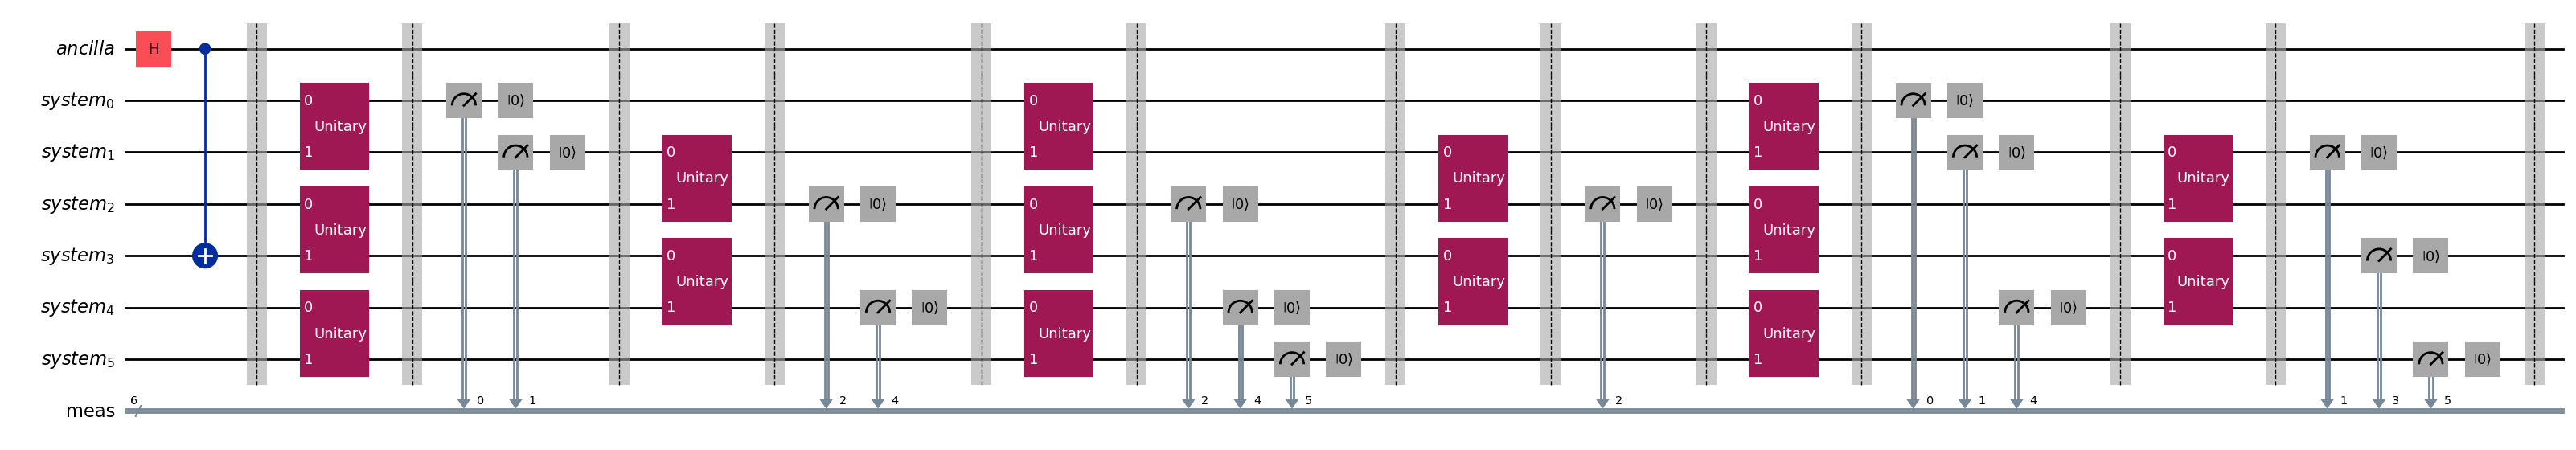

p=0.00  <S_ancilla>=1.000 ± 0.000
p=0.10  <S_ancilla>=0.761 ± 0.025
p=0.20  <S_ancilla>=0.485 ± 0.033
p=0.30  <S_ancilla>=0.318 ± 0.028
p=0.40  <S_ancilla>=0.131 ± 0.020
p=0.60  <S_ancilla>=0.015 ± 0.007
p=0.80  <S_ancilla>=0.000 ± 0.000


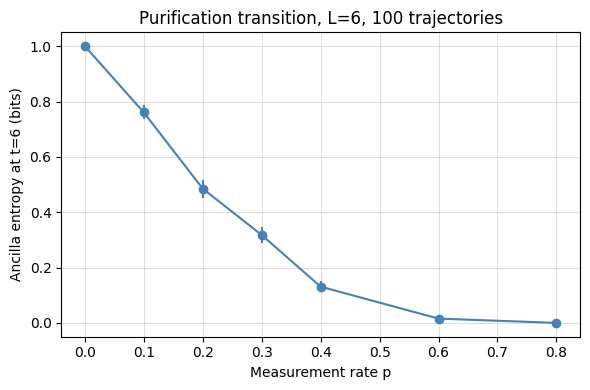

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import random_unitary, partial_trace, entropy
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

rng = np.random.default_rng()
sim = AerSimulator(method='density_matrix')


def build_trajectory_circuit(size, T, p_measure, seed=None):
    """
    Ancilla (qubit 0) Bell-paired to the middle system qubit, followed by
    T brickwork layers of random 2-qubit unitaries with per-qubit
    mid-circuit measurement/reset at rate p_measure.
    """
    local_rng = np.random.default_rng(seed)

    Ancilla = QuantumRegister(1, 'ancilla')
    System = QuantumRegister(size, 'system')
    Creg = ClassicalRegister(size, 'meas')
    qc = QuantumCircuit(Ancilla, System, Creg)

    # Entangle ancilla with the middle system qubit
    qc.h(Ancilla[0])
    qc.cx(Ancilla[0], System[size // 2])
    qc.barrier()

    system_qubits = list(range(1, size + 1))  # global indices (0 = ancilla)

    for t in range(T):
        # --- brickwork layer of random 2-qubit gates ---
        offset = t % 2
        j = offset
        while j + 1 < size:
            u2 = random_unitary(4, seed=local_rng.integers(1 << 30))
            qc.append(UnitaryGate(u2), [system_qubits[j], system_qubits[j + 1]])
            j += 2
        qc.barrier()

        # --- per-qubit measurement with probability p_measure ---
        for k, q in enumerate(system_qubits):
            if local_rng.random() < p_measure:
                qc.measure(q, Creg[k])
                qc.reset(q)
        qc.barrier()

    return qc


def run_trajectory(size, T, p_measure, seed=None):
    qc = build_trajectory_circuit(size, T, p_measure, seed=seed)
    qc.save_density_matrix()
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=1).result()
    rho_full = result.data(0)['density_matrix']
    rho_ancilla = partial_trace(rho_full, list(range(1, size + 1)))
    return entropy(rho_ancilla, base=2)


def run_averaged(size, T, p_measure, n_trials=100):
    entropies = np.array([
        run_trajectory(size, T, p_measure, seed=trial)
        for trial in range(n_trials)
    ])
    return entropies.mean(), entropies.std() / np.sqrt(n_trials)


# --- Show one example circuit for presentation ---
example_qc = build_trajectory_circuit(size=6, T=6, p_measure=0.4, seed=0)
print("Example system with the size=6, Depth=6, and measurement rate=0.4 ")
display(example_qc.draw('mpl', fold=-1))

# --- Sweep over measurement rate p, averaging entropy at final time T ---
size = 6
T = 6
n_trials = 100
p_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8]

mean_entropies = []
sem_entropies = []
for p in p_values:
    m, s = run_averaged(size, T, p, n_trials=n_trials)
    mean_entropies.append(m)
    sem_entropies.append(s)
    print(f"p={p:.2f}  <S_ancilla>={m:.3f} ± {s:.3f}")

plt.figure(figsize=(6, 4))
plt.errorbar(p_values, mean_entropies, yerr=sem_entropies, marker='o', color='steelblue')
plt.xlabel("Measurement rate p")
plt.ylabel(f"Ancilla entropy at t={T} (bits)")
plt.title(f"Purification transition, L={size}, {n_trials} trajectories")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Example system with the size=6, Depth=6, and measurement rate=0.4 


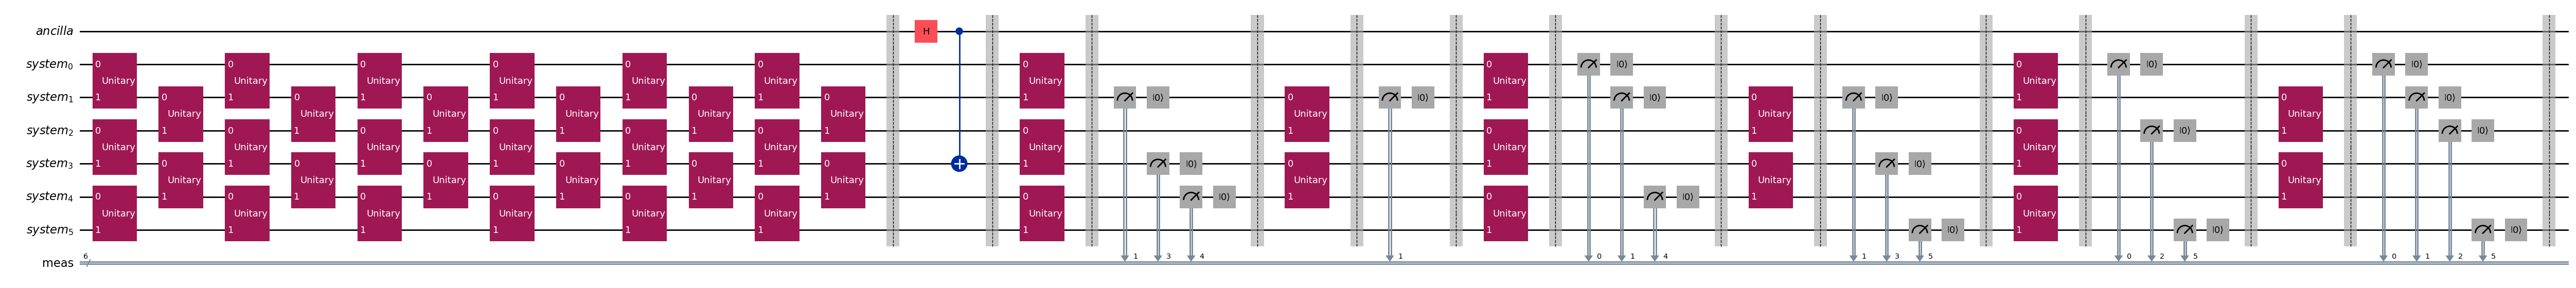

p=0.00  <S_ancilla>=0.988 ± 0.002
p=0.10  <S_ancilla>=0.853 ± 0.017
p=0.20  <S_ancilla>=0.619 ± 0.027
p=0.30  <S_ancilla>=0.412 ± 0.032
p=0.40  <S_ancilla>=0.215 ± 0.029
p=0.60  <S_ancilla>=0.018 ± 0.007
p=0.80  <S_ancilla>=0.001 ± 0.001


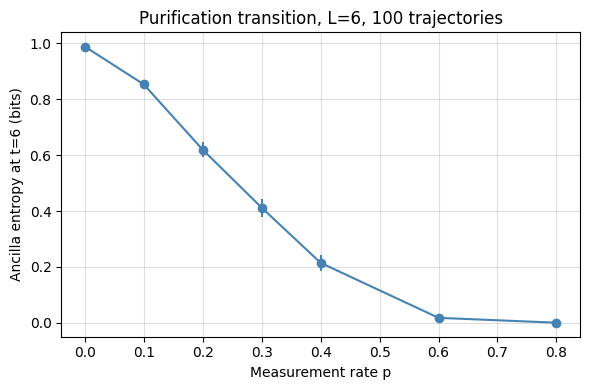

In [17]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import random_unitary, partial_trace, entropy
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

rng = np.random.default_rng()
sim = AerSimulator(method='density_matrix')


def build_trajectory_circuit_scrambled(size, T, p_measure, t_scramble=4, seed=None):
    local_rng = np.random.default_rng(seed)

    Ancilla = QuantumRegister(1, 'ancilla')
    System = QuantumRegister(size, 'system')
    Creg = ClassicalRegister(size, 'meas')
    qc = QuantumCircuit(Ancilla, System, Creg)

    system_qubits_local = list(range(size))       # 0-indexed within System register
    system_qubits_global = list(range(1, size+1)) # global indices (0 = ancilla)

    # --- Phase 1: scramble the system ALONE, ancilla untouched ---
    for t in range(t_scramble):
        offset = t % 2
        j = offset
        while j + 1 < size:
            u2 = random_unitary(4, seed=local_rng.integers(1 << 30))
            qc.append(UnitaryGate(u2), [System[j], System[j + 1]])
            j += 2
    qc.barrier()

    # --- Phase 2: NOW couple ancilla to the scrambled system ---
    qc.h(Ancilla[0])
    qc.cx(Ancilla[0], System[size // 2])
    qc.barrier()

    # --- Phase 3: monitored dynamics (same as before) ---
    for t in range(T):
        offset = t % 2
        j = offset
        while j + 1 < size:
            u2 = random_unitary(4, seed=local_rng.integers(1 << 30))
            qc.append(UnitaryGate(u2), [system_qubits_global[j], system_qubits_global[j + 1]])
            j += 2
        qc.barrier()

        for k, q in enumerate(system_qubits_global):
            if local_rng.random() < p_measure:
                qc.measure(q, Creg[k])
                qc.reset(q)
        qc.barrier()

    return qc


def run_trajectory(size, T, p_measure, seed=None):
    qc = build_trajectory_circuit_scrambled(size, T, p_measure, scramble, seed=seed)
    qc.save_density_matrix()
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=1).result()
    rho_full = result.data(0)['density_matrix']
    rho_ancilla = partial_trace(rho_full, list(range(1, size + 1)))
    return entropy(rho_ancilla, base=2)


def run_averaged(size, T, p_measure, n_trials=100):
    entropies = np.array([
        run_trajectory(size, T, p_measure, seed=trial)
        for trial in range(n_trials)
    ])
    return entropies.mean(), entropies.std() / np.sqrt(n_trials)


# --- Show one example circuit for presentation ---
example_qc = build_trajectory_circuit_scrambled(size=6, T=6, p_measure=0.4, t_scramble=12, seed=0)
print("Example system with the size=6, Depth=6, and measurement rate=0.4 ")
display(example_qc.draw('mpl', fold=-1))

# --- Sweep over measurement rate p, averaging entropy at final time T ---
size = 6
T = 6
scramble = 12
n_trials = 100
p_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8]

mean_entropies = []
sem_entropies = []
for p in p_values:
    m, s = run_averaged(size, T, p, n_trials=n_trials)
    mean_entropies.append(m)
    sem_entropies.append(s)
    print(f"p={p:.2f}  <S_ancilla>={m:.3f} ± {s:.3f}")

plt.figure(figsize=(6, 4))
plt.errorbar(p_values, mean_entropies, yerr=sem_entropies, marker='o', color='steelblue')
plt.xlabel("Measurement rate p")
plt.ylabel(f"Ancilla entropy at t={T} (bits)")
plt.title(f"Purification transition, L={size}, {n_trials} trajectories")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

#GPU

device: cuda


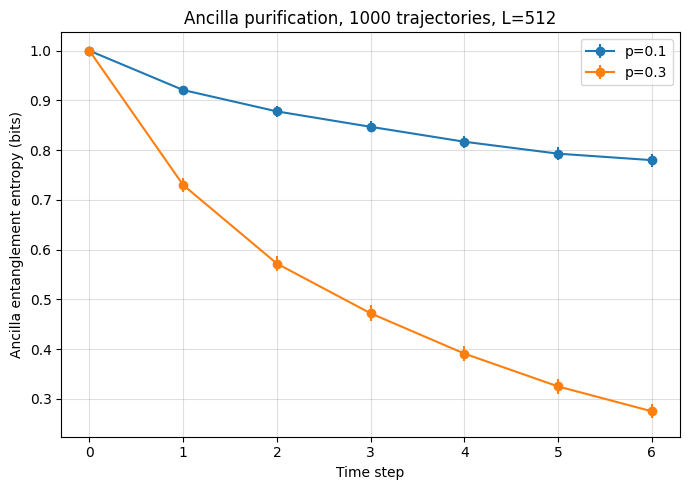

CPU times: user 1min 26s, sys: 3.75 s, total: 1min 30s
Wall time: 1min 32s


In [7]:
%%time

import numpy as np
import torch
import os

# ---------------- Sp(4,2) precomputation (720 elements, one-time, cached) ----------------

def gf2_rank_full(matrix):
    m = (matrix.copy() % 2).astype(np.uint8)
    rows, cols = m.shape
    rank = 0
    for col in range(cols):
        pivot = None
        for r in range(rank, rows):
            if m[r, col]:
                pivot = r
                break
        if pivot is None:
            continue
        m[[rank, pivot]] = m[[pivot, rank]]
        for r in range(rows):
            if r != rank and m[r, col]:
                m[r] = (m[r] + m[rank]) % 2
        rank += 1
    return rank


def build_sp42(cache_path="sp42_table.npy"):
    if os.path.exists(cache_path):
        return np.load(cache_path)
    idx = np.arange(1 << 16, dtype=np.uint32)
    bits = ((idx[:, None] >> np.arange(16)) & 1).astype(np.uint8)
    mats = bits.reshape(-1, 4, 4)
    J = np.array([[0, 1, 0, 0],
                  [1, 0, 0, 0],
                  [0, 0, 0, 1],
                  [0, 0, 1, 0]], dtype=np.uint8)
    valid = []
    for M in mats:
        if gf2_rank_full(M) < 4:
            continue
        lhs = (M.T.astype(np.uint8) @ J @ M) % 2
        if np.array_equal(lhs, J):
            valid.append(M)
    table = np.stack(valid).astype(np.uint8)
    np.save(cache_path, table)
    return table


# ---------------- Tableau gate primitives (batched, in-place where possible) ----------------

def apply_hadamard(X, Z, q):
    xq = X[:, :, q].clone()
    zq = Z[:, :, q].clone()
    X[:, :, q] = zq
    Z[:, :, q] = xq


def apply_cnot(X, Z, c, t):
    X[:, :, t] ^= X[:, :, c]
    Z[:, :, c] ^= Z[:, :, t]


def apply_two_qubit_random(X, Z, a, b, sp42_table, batch, device, generator=None):
    n_elems = sp42_table.shape[0]
    idx = torch.randint(0, n_elems, (batch,), device=device, generator=generator)
    M = sp42_table[idx].float()  # (batch,4,4)
    vec = torch.stack([X[:, :, a], Z[:, :, a], X[:, :, b], Z[:, :, b]], dim=-1).float()  # (batch,n,4)
    new_vec = torch.einsum('bkl,bnl->bnk', M, vec)
    new_vec = torch.remainder(new_vec, 2).to(torch.uint8)
    X[:, :, a] = new_vec[..., 0]
    Z[:, :, a] = new_vec[..., 1]
    X[:, :, b] = new_vec[..., 2]
    Z[:, :, b] = new_vec[..., 3]


def brickwork_layer_batched(X, Z, t, system_qubits, sp42_table, batch, device, periodic=True, generator=None):
    L = len(system_qubits)
    offset = t % 2
    j = offset
    while j + 1 < L:
        apply_two_qubit_random(X, Z, system_qubits[j], system_qubits[j + 1], sp42_table, batch, device, generator)
        j += 2
    if periodic and offset == 1 and L % 2 == 0:
        apply_two_qubit_random(X, Z, system_qubits[L - 1], system_qubits[0], sp42_table, batch, device, generator)


def measure_layer_batched(X, Z, system_qubits, p_measure, batch, device, generator=None):
    do_measure = torch.rand((batch, len(system_qubits)), device=device, generator=generator) < p_measure
    b_idx = torch.arange(batch, device=device)
    for k, q in enumerate(system_qubits):
        mask_q = do_measure[:, k]
        if not mask_q.any():
            continue
        x_col = X[:, :, q]
        anticommute = (x_col == 1)
        any_anti = anticommute.any(dim=1)
        is_random = any_anti & mask_q
        if not is_random.any():
            continue
        pivot_idx = torch.argmax(anticommute.to(torch.int64), dim=1)
        pivot_X = X[b_idx, pivot_idx, :].clone()
        pivot_Z = Z[b_idx, pivot_idx, :].clone()
        upd_mask = anticommute.clone()
        upd_mask[b_idx, pivot_idx] = False
        upd_mask = (upd_mask & is_random.unsqueeze(1)).to(torch.uint8)
        X ^= upd_mask.unsqueeze(-1) * pivot_X.unsqueeze(1)
        Z ^= upd_mask.unsqueeze(-1) * pivot_Z.unsqueeze(1)
        reset_x_row = torch.zeros_like(pivot_X)
        reset_z_row = torch.zeros_like(pivot_Z)
        reset_z_row[:, q] = 1
        sel = is_random  # (batch,)
        new_pivot_X = torch.where(sel.unsqueeze(-1), reset_x_row, pivot_X)
        new_pivot_Z = torch.where(sel.unsqueeze(-1), reset_z_row, pivot_Z)
        X[b_idx, pivot_idx, :] = new_pivot_X
        Z[b_idx, pivot_idx, :] = new_pivot_Z
    return X, Z


def ancilla_entropy_batched(X, Z, ancilla_col=0):
    x_col = X[:, :, ancilla_col]
    z_col = Z[:, :, ancilla_col]
    pat1 = ((x_col == 0) & (z_col == 1)).any(dim=1)
    pat2 = ((x_col == 1) & (z_col == 0)).any(dim=1)
    pat3 = ((x_col == 1) & (z_col == 1)).any(dim=1)
    distinct = pat1.to(torch.int64) + pat2.to(torch.int64) + pat3.to(torch.int64)
    rank = torch.clamp(distinct, max=2)
    return (rank - 1).float()


def run_averaged_gpu(size, T, p_measure, n_trials=1000, periodic=True, device=None, sp42_table=None, seed=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if sp42_table is None:
        sp42_table = torch.tensor(build_sp42(), dtype=torch.uint8, device=device)
    generator = None
    if seed is not None:
        generator = torch.Generator(device=device)
        generator.manual_seed(seed)

    n = size + 1
    system_qubits = list(range(1, size + 1))
    X = torch.zeros((n_trials, n, n), dtype=torch.uint8, device=device)
    Z = torch.zeros((n_trials, n, n), dtype=torch.uint8, device=device)
    Z[:, torch.arange(n), torch.arange(n)] = 1

    apply_hadamard(X, Z, 0)
    apply_cnot(X, Z, 0, size // 2 + 1)

    entropy_hist = torch.zeros((n_trials, T), device=device)
    entropy_hist[:, 0] = ancilla_entropy_batched(X, Z, 0)
    for t in range(1, T):
        brickwork_layer_batched(X, Z, t, system_qubits, sp42_table, n_trials, device, periodic=periodic, generator=generator)
        X, Z = measure_layer_batched(X, Z, system_qubits, p_measure, n_trials, device, generator=generator)
        entropy_hist[:, t] = ancilla_entropy_batched(X, Z, 0)

    mean_S = entropy_hist.mean(dim=0).cpu().numpy()
    sem_S = (entropy_hist.std(dim=0) / (n_trials ** 0.5)).cpu().numpy()
    return mean_S, sem_S


if __name__ == "__main__":
    import matplotlib.pyplot as plt

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("device:", device)
    table = build_sp42()  # cached to sp42_table.npy after first run
    sp42_t = torch.tensor(table, dtype=torch.uint8, device=device)

    size = 512
    T = 7
    n_trials = 1000

    plt.figure(figsize=(7, 5))
    for p in [0.1, 0.3]:
        mean_S, sem_S = run_averaged_gpu(
            size=size, T=T, p_measure=p, n_trials=n_trials,
            sp42_table=sp42_t, device=device,
        )
        plt.errorbar(range(0, T), mean_S, yerr=sem_S, marker='o', label=f"p={p}")

    plt.xlabel("Time step")
    plt.ylabel("Ancilla entanglement entropy (bits)")
    plt.title(f"Ancilla purification, {n_trials} trajectories, L={size}")
    plt.legend()
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.savefig("mipt_result.png", dpi=150)
    plt.show()

#Half entropy

device: cuda
[1/11] p=0.00 done in 3s | elapsed 3s | remaining ~28s (ETA 00:16:20)
[2/11] p=0.02 done in 3s | elapsed 6s | remaining ~28s (ETA 00:16:24)
[3/11] p=0.04 done in 4s | elapsed 10s | remaining ~27s (ETA 00:16:26)
[4/11] p=0.06 done in 3s | elapsed 14s | remaining ~24s (ETA 00:16:27)
[5/11] p=0.08 done in 3s | elapsed 17s | remaining ~20s (ETA 00:16:27)
[6/11] p=0.10 done in 4s | elapsed 21s | remaining ~17s (ETA 00:16:28)
[7/11] p=0.12 done in 3s | elapsed 24s | remaining ~14s (ETA 00:16:28)
[8/11] p=0.14 done in 3s | elapsed 28s | remaining ~10s (ETA 00:16:28)
[9/11] p=0.16 done in 4s | elapsed 32s | remaining ~7s (ETA 00:16:28)
[10/11] p=0.18 done in 4s | elapsed 35s | remaining ~4s (ETA 00:16:28)
[11/11] p=0.20 done in 3s | elapsed 39s | remaining ~0s (ETA 00:16:28)
Total wall time: 39s


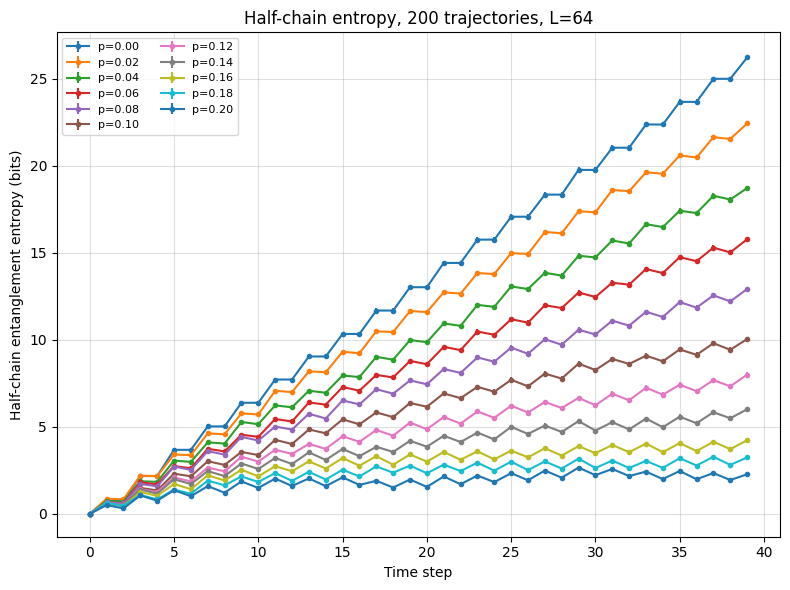

In [5]:
import numpy as np
import torch
import os
import time
import datetime

# ---------------- Sp(4,2) precomputation (720 elements, one-time, cached) ----------------

def gf2_rank_full(matrix):
    m = (matrix.copy() % 2).astype(np.uint8)
    rows, cols = m.shape
    rank = 0
    for col in range(cols):
        pivot = None
        for r in range(rank, rows):
            if m[r, col]:
                pivot = r
                break
        if pivot is None:
            continue
        m[[rank, pivot]] = m[[pivot, rank]]
        for r in range(rows):
            if r != rank and m[r, col]:
                m[r] = (m[r] + m[rank]) % 2
        rank += 1
    return rank


def build_sp42(cache_path="sp42_table.npy"):
    if os.path.exists(cache_path):
        return np.load(cache_path)
    idx = np.arange(1 << 16, dtype=np.uint32)
    bits = ((idx[:, None] >> np.arange(16)) & 1).astype(np.uint8)
    mats = bits.reshape(-1, 4, 4)
    J = np.array([[0, 1, 0, 0],
                  [1, 0, 0, 0],
                  [0, 0, 0, 1],
                  [0, 0, 1, 0]], dtype=np.uint8)
    valid = []
    for M in mats:
        if gf2_rank_full(M) < 4:
            continue
        lhs = (M.T.astype(np.uint8) @ J @ M) % 2
        if np.array_equal(lhs, J):
            valid.append(M)
    table = np.stack(valid).astype(np.uint8)
    np.save(cache_path, table)
    return table


# ---------------- Tableau gate primitives (batched, in-place where possible) ----------------

def apply_hadamard(X, Z, q):
    xq = X[:, :, q].clone()
    zq = Z[:, :, q].clone()
    X[:, :, q] = zq
    Z[:, :, q] = xq


def apply_cnot(X, Z, c, t):
    X[:, :, t] ^= X[:, :, c]
    Z[:, :, c] ^= Z[:, :, t]


def apply_two_qubit_random(X, Z, a, b, sp42_table, batch, device, generator=None):
    n_elems = sp42_table.shape[0]
    idx = torch.randint(0, n_elems, (batch,), device=device, generator=generator)
    M = sp42_table[idx].float()  # (batch,4,4)
    vec = torch.stack([X[:, :, a], Z[:, :, a], X[:, :, b], Z[:, :, b]], dim=-1).float()  # (batch,n,4)
    new_vec = torch.einsum('bkl,bnl->bnk', M, vec)
    new_vec = torch.remainder(new_vec, 2).to(torch.uint8)
    X[:, :, a] = new_vec[..., 0]
    Z[:, :, a] = new_vec[..., 1]
    X[:, :, b] = new_vec[..., 2]
    Z[:, :, b] = new_vec[..., 3]


def brickwork_layer_batched(X, Z, t, system_qubits, sp42_table, batch, device, periodic=True, generator=None):
    L = len(system_qubits)
    offset = t % 2
    j = offset
    while j + 1 < L:
        apply_two_qubit_random(X, Z, system_qubits[j], system_qubits[j + 1], sp42_table, batch, device, generator)
        j += 2
    if periodic and offset == 1 and L % 2 == 0:
        apply_two_qubit_random(X, Z, system_qubits[L - 1], system_qubits[0], sp42_table, batch, device, generator)


def measure_layer_batched(X, Z, system_qubits, p_measure, batch, device, generator=None):
    do_measure = torch.rand((batch, len(system_qubits)), device=device, generator=generator) < p_measure
    b_idx = torch.arange(batch, device=device)
    for k, q in enumerate(system_qubits):
        mask_q = do_measure[:, k]
        if not mask_q.any():
            continue
        x_col = X[:, :, q]
        anticommute = (x_col == 1)
        any_anti = anticommute.any(dim=1)
        is_random = any_anti & mask_q
        if not is_random.any():
            continue
        pivot_idx = torch.argmax(anticommute.to(torch.int64), dim=1)
        pivot_X = X[b_idx, pivot_idx, :].clone()
        pivot_Z = Z[b_idx, pivot_idx, :].clone()
        upd_mask = anticommute.clone()
        upd_mask[b_idx, pivot_idx] = False
        upd_mask = (upd_mask & is_random.unsqueeze(1)).to(torch.uint8)
        X ^= upd_mask.unsqueeze(-1) * pivot_X.unsqueeze(1)
        Z ^= upd_mask.unsqueeze(-1) * pivot_Z.unsqueeze(1)
        reset_x_row = torch.zeros_like(pivot_X)
        reset_z_row = torch.zeros_like(pivot_Z)
        reset_z_row[:, q] = 1
        sel = is_random  # (batch,)
        new_pivot_X = torch.where(sel.unsqueeze(-1), reset_x_row, pivot_X)
        new_pivot_Z = torch.where(sel.unsqueeze(-1), reset_z_row, pivot_Z)
        X[b_idx, pivot_idx, :] = new_pivot_X
        Z[b_idx, pivot_idx, :] = new_pivot_Z
    return X, Z




def gf2_rank_batched(M, device):
    """Batched GF(2) rank via bit-packed Gaussian elimination.
    M: (batch, rows, cols) uint8 tensor of 0/1 entries. Returns (batch,) int64 ranks.
    """
    batch, rows, cols = M.shape
    word = 32
    num_words = (cols + word - 1) // word
    pad = num_words * word - cols
    if pad:
        M = torch.nn.functional.pad(M, (0, pad))
    M_r = M.view(batch, rows, num_words, word).to(torch.int64)
    weights = (2 ** torch.arange(word, device=device, dtype=torch.int64))
    packed = (M_r * weights).sum(dim=-1)  # (batch, rows, num_words)

    rank_ptr = torch.zeros(batch, dtype=torch.int64, device=device)
    b_idx = torch.arange(batch, device=device)
    row_ar = torch.arange(rows, device=device)

    for c in range(cols):
        w = c // word
        bit = c % word
        col_bits = ((packed[:, :, w] >> bit) & 1).to(torch.uint8)
        available = row_ar.unsqueeze(0) >= rank_ptr.unsqueeze(1)
        candidate = available & (col_bits == 1)
        sentinel = rows
        idx_grid = row_ar.unsqueeze(0).expand(batch, rows)
        masked_idx = torch.where(candidate, idx_grid, torch.full_like(idx_grid, sentinel))
        pivot_idx = masked_idx.min(dim=1).values
        has_pivot = pivot_idx < sentinel
        safe_rank_ptr = torch.clamp(rank_ptr, max=rows - 1)
        safe_pivot = torch.clamp(torch.where(has_pivot, pivot_idx, rank_ptr), max=rows - 1)

        row_rank = packed[b_idx, safe_rank_ptr, :].clone()
        row_pivot = packed[b_idx, safe_pivot, :].clone()
        new_row_rank = torch.where(has_pivot.unsqueeze(-1), row_pivot, row_rank)
        new_row_pivot = torch.where(has_pivot.unsqueeze(-1), row_rank, row_pivot)
        packed[b_idx, safe_rank_ptr, :] = new_row_rank
        packed[b_idx, safe_pivot, :] = new_row_pivot

        col_bits_after = ((packed[:, :, w] >> bit) & 1).to(torch.uint8)
        elim_mask = col_bits_after.clone()
        elim_mask[b_idx, safe_rank_ptr] = 0
        elim_mask = elim_mask & has_pivot.unsqueeze(1)
        target_row = packed[b_idx, safe_rank_ptr, :]
        packed ^= elim_mask.unsqueeze(-1).to(torch.int64) * target_row.unsqueeze(1)

        rank_ptr = rank_ptr + has_pivot.to(torch.int64)
    return rank_ptr


def half_chain_entropy_batched(X, Z, region_a_cols, device):
    """S_A = rank_GF2([X_A | Z_A]) - |A|, for region_a_cols a LongTensor of qubit indices."""
    if not torch.is_tensor(region_a_cols):
        region_a_cols = torch.tensor(region_a_cols, dtype=torch.long, device=device)
    X_A = X[:, :, region_a_cols]  # (batch, rows, |A|)
    Z_A = Z[:, :, region_a_cols]
    M_A = torch.cat([X_A, Z_A], dim=-1)  # (batch, rows, 2|A|)
    rank = gf2_rank_batched(M_A, device)
    return (rank - region_a_cols.numel()).float()


def format_duration(seconds):
    seconds = max(0, int(round(seconds)))
    h, rem = divmod(seconds, 3600)
    m, s = divmod(rem, 60)
    if h:
        return f"{h}h {m}m {s}s"
    if m:
        return f"{m}m {s}s"
    return f"{s}s"


def run_averaged_gpu(size, T, p_measure, n_trials=1000, periodic=True, device=None, sp42_table=None, seed=None):
    """No ancilla. Tracks half-chain (first size//2 qubits) entanglement entropy vs time."""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if sp42_table is None:
        sp42_table = torch.tensor(build_sp42(), dtype=torch.uint8, device=device)
    generator = None
    if seed is not None:
        generator = torch.Generator(device=device)
        generator.manual_seed(seed)

    n = size
    system_qubits = list(range(size))
    region_a = torch.arange(size // 2, device=device)  # first half of the chain

    X = torch.zeros((n_trials, n, n), dtype=torch.uint8, device=device)
    Z = torch.zeros((n_trials, n, n), dtype=torch.uint8, device=device)
    Z[:, torch.arange(n), torch.arange(n)] = 1  # product state |0...0>

    entropy_hist = torch.zeros((n_trials, T), device=device)
    entropy_hist[:, 0] = half_chain_entropy_batched(X, Z, region_a, device)
    for t in range(1, T):
        brickwork_layer_batched(X, Z, t, system_qubits, sp42_table, n_trials, device, periodic=periodic, generator=generator)
        X, Z = measure_layer_batched(X, Z, system_qubits, p_measure, n_trials, device, generator=generator)
        entropy_hist[:, t] = half_chain_entropy_batched(X, Z, region_a, device)

    mean_S = entropy_hist.mean(dim=0).cpu().numpy()
    sem_S = (entropy_hist.std(dim=0) / (n_trials ** 0.5)).cpu().numpy()
    return mean_S, sem_S


if __name__ == "__main__":
    import matplotlib.pyplot as plt

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("device:", device)
    table = build_sp42()  # cached to sp42_table.npy after first run
    sp42_t = torch.tensor(table, dtype=torch.uint8, device=device)

    size = 64
    T = 40
    n_trials = 200
    p_values = np.round(np.arange(0.0, 0.2 + 1e-9, 0.02), 2)

    plt.figure(figsize=(8, 6))
    run_times = []
    n_total = len(p_values)
    overall_start = time.time()
    for i, p in enumerate(p_values):
        t0 = time.time()
        mean_S, sem_S = run_averaged_gpu(
            size=size, T=T, p_measure=float(p), n_trials=n_trials,
            sp42_table=sp42_t, device=device,
        )
        dt = time.time() - t0
        run_times.append(dt)

        avg_dt = sum(run_times) / len(run_times)
        remaining = avg_dt * (n_total - (i + 1))
        eta_clock = datetime.datetime.now() + datetime.timedelta(seconds=remaining)
        print(
            f"[{i + 1}/{n_total}] p={p:.2f} done in {format_duration(dt)} | "
            f"elapsed {format_duration(time.time() - overall_start)} | "
            f"remaining ~{format_duration(remaining)} "
            f"(ETA {eta_clock.strftime('%H:%M:%S')})"
        )

        plt.errorbar(range(0, T), mean_S, yerr=sem_S, marker='o', markersize=3, label=f"p={p:.2f}")

    print(f"Total wall time: {format_duration(time.time() - overall_start)}")

    plt.xlabel("Time step")
    plt.ylabel("Half-chain entanglement entropy (bits)")
    plt.title(f"Half-chain entropy, {n_trials} trajectories, L={size}")
    plt.legend(fontsize=8, ncol=2)
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.savefig("mipt_result.png", dpi=150)
    plt.show()

This function simulates the **entanglement dynamics of an ancilla qubit coupled to a many-qubit quantum system** under a random circuit with measurements. It tracks how much information about the system is stored in the ancilla over time by measuring the ancilla's entropy.

At a high level:

1. Prepare a system of `size` qubits and one ancilla qubit.
2. Optionally scramble the system before coupling the ancilla.
3. Entangle the ancilla with the system.
4. Evolve the system through repeated layers of gates and measurements.
5. At each time step, compute the ancilla entropy.
6. Return the entropy history.

**Case 1: Scrambling before coupling**

```python
if t_scramble > 0:
```

This branch first evolves the system alone.

The idea is:

> Let the system become chaotic/scrambled before attaching the ancilla.

---

**Create a system-only circuit**

```python
qc_sys = qiskit.QuantumCircuit(size)
state = qi.StabilizerState(qc_sys)
```

The system starts as:

[
|000...0\rangle
]

represented as a stabilizer state.

---

**Apply random brickwork layers**

```python
for t in range(t_scramble):
    state = brickwork_layer(
        state,
        list(range(size)),
        t,
        periodic=periodic
    )
```

This applies your custom `brickwork_layer`.

Usually a brickwork circuit means alternating two-qubit gates:

Example:

time 0:

```
0--1   2--3   4--5
```

time 1:

```
 0--1   2--3   4--5
```

shifted by one site:

```
1--2   3--4   5--6
```

The goal is to spread local information throughout the chain.

---

**Embed the scrambled system into ancilla+system space**

```python
full_qc = qiskit.QuantumCircuit(Ancilla, System)
state = qi.StabilizerState(full_qc).evolve(...)
```

This takes the scrambled `size`-qubit state and places it into:

[
|0\rangle_a\otimes |\psi\rangle_s
]

so the ancilla is still independent.

---

**Apply Hadamard to ancilla**

```python
qc2 = qiskit.QuantumCircuit(1)
qc2.h(0)
state = state.evolve(qi.Clifford(qc2), qargs=[0])
```

This prepares:

[
|+\rangle_a
===========

\frac{|0\rangle+|1\rangle}{\sqrt 2}
]

The ancilla is now a quantum reference.

---

**Entangle ancilla with system**

```python
cx.cx(0,1)
```

Actually:

```python
state.evolve(qi.Clifford(cx),
             qargs=[0,size//2+1])
```

applies:

[
CX_{ancilla \rightarrow center\ qubit}
]

The ancilla becomes entangled with the middle system qubit.

So:

[
|+\rangle_a |\psi\rangle_s
\rightarrow
\frac{|0\rangle|\psi\rangle
+
|1\rangle X_i|\psi\rangle}{\sqrt2}
]

The ancilla now stores information about the system.

---

# Case 2: No scrambling

```python
else:
```

Simpler initialization.

---

Prepare ancilla:

```python
qc.h(Ancilla)
```

Creates:

[
|+\rangle_a
]

---

Entangle with the middle system qubit:

```python
qc.cx(Ancilla,System[size//2])
```

So initially:

```
ancilla
   |
   v
middle system qubit
```

is entangled.

---

**Main evolution loop**

```python
entropy_history=np.zeros(T)

for t in range(T):
```

Now simulate the monitored quantum dynamics.

---

**Apply unitary scrambling**

```python
state = brickwork_layer(
    state,
    system_qubits,
    t,
    periodic=periodic
)
```

Each timestep applies a layer of two-qubit Clifford gates.

This spreads the ancilla information through the system.

Physically:

[
\text{local information}
\rightarrow
\text{many-body correlations}
]

---

**Apply measurements**

```python
state = measure_layer(
    state,
    system_qubits,
    p_measure
)
```

Each system qubit is measured with probability:

[
p_{measure}
]

This creates a **hybrid unitary-measurement circuit**.

Small (p):

* mostly unitary
* information spreads

Large (p):

* measurements destroy entanglement
* information gets localized

This is the setup used in studies of **measurement-induced phase transitions**.

---

**Compute ancilla entropy**

```python
entropy_history[t]=ancilla_entropy(
    state,
    ancilla_col=0
)
```

Calculates the entropy of the ancilla:

[
S_a=-Tr(\rho_a\log_2\rho_a)
]

For a single qubit:

* (S=0): ancilla is pure, no entanglement
* (S=1): maximally entangled with the system

---

Finally:

```python
return entropy_history
```

returns:

```
time      entropy
0         0.3
1         0.7
2         0.9
...
T         ...
```

---

**Physical interpretation**

This function is essentially measuring **how quickly quantum information injected by an ancilla spreads and is destroyed by measurements**.

It is a numerical experiment for:

* monitored quantum circuits
* scrambling
* quantum information spreading
* measurement-induced entanglement transitions
* quantum error correction dynamics

The key observable is:

[
S_{ancilla}(t)
]

which tells you whether the system still "remembers" the ancilla.

---

One subtle point: the `t_scramble > 0` branch is doing a **pre-scrambling quench** where the system evolves before the ancilla is attached. The `else` branch instead attaches the ancilla immediately at (t=0). These two cases are not physically equivalent: they probe different questions about information spreading.


In [ ]:
def run_trajectory(size, T, p_measure, t_scramble=0, periodic=True):
    Ancilla = qiskit.QuantumRegister(1, 'ancilla')
    System = qiskit.QuantumRegister(size, 'system')
    qc = qiskit.QuantumCircuit(Ancilla, System)
    state = qi.StabilizerState(qc)  # single tableau, (size+1) qubits, ancilla = qubit 0

    system_qubits = list(range(1, size + 1))  # global indices; ancilla = 0

    if t_scramble > 0: # Optional Scrambling
    # Phase 1: scramble the system alone, directly on the same tableau.
    for t in range(t_scramble):
        state = brickwork_layer(state, system_qubits, t, periodic=periodic)

    # Phase 2: couple ancilla to the (now scrambled, or trivial if t_scramble=0) system
    h_gate = QuantumCircuit(1); h_gate.h(0)
    state = state.evolve(qi.Clifford(h_gate), qargs=[0])

    cx_gate = QuantumCircuit(2); cx_gate.cx(0, 1)
    state = state.evolve(qi.Clifford(cx_gate), qargs=[0, size // 2 + 1])

    # Phase 3: monitored dynamics
    entropy_history = np.zeros(T)
    for t in range(T):
        state = brickwork_layer(state, system_qubits, t, periodic=periodic)
        state = measure_layer(state, system_qubits, p_measure)
        entropy_history[t] = ancilla_entropy(state, ancilla_col=0)
    return entropy_history